LOADING THE DATASET

In [ ]:
import pandas as pd



In [ ]:
df=pd.read_csv('/content/Balanced_dataset.csv')
df.shape

(12500, 2)

In [ ]:
df.columns

Index(['rating', 'review'], dtype='object')

In [ ]:
df['review']=df['review'].astype(str).str.lower()

In [ ]:
df.shape

(12500, 2)

In [ ]:
df.head(5)

,rating,review
0,1,very bad product it hangs frequently
1,1,i couldnt wait to get this top in the mail sin...
2,1,i bought a pair of these a month ago and first...
3,1,after reading the previous review i was pretty...
4,1,very bad product battery drains out in minutes...


In [ ]:
df['rating'].value_counts()

,count
rating,
1,2500
2,2500
3,2500
4,2500
5,2500


In [ ]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = df[df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. i ran several tests both on my computer and my phone it wrote at mb and read at about to depeneding on its mood i bought this to replace a generic gb class card that i lost so dang small i droped it and could not find it that card actual wrote at to mb and read at mb i went with sandisk because my phone came with a class that performs more like a class what a waste of time refunded this item

2. i was very disappointed with this recipe i agree with tilda it was dry and had no flavor i was expecting an orangey tasting cake and could taste no orange i made this for my grandson age and he did not care for it at all he loves everything i make for him and is so easy to please but this did not please had to throw it away

3. quality of display is bad i got effective speakers and no microsoft installed waste for money they are not replacing also so dont buyy

4. this dress is so cute i went to the store to try it on and although i knew the dress w

REMOVING STOPWORDS

In [ ]:
%pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(str(text))  # tokenize text
    filtered = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered)


df['review']=df['review'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
stop_words = set(stopwords.words('english'))

# Display total count and all stopwords
print("Total stopwords:", len(stop_words))
print(sorted(stop_words))  # Sorted alphabetically

Total stopwords: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", "he's", 'her', 'here', 'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', "i'd", "i'll", "i'm", "i've", 'if', 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', '

In [ ]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = df[df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. i ran several tests both on my computer and my phone it wrote at mb and read at about to depeneding on its mood i bought this to replace a generic gb class card that i lost so dang small i droped it and could not find it that card actual wrote at to mb and read at mb i went with sandisk because my phone came with a class that performs more like a class what a waste of time refunded this item

2. i was very disappointed with this recipe i agree with tilda it was dry and had no flavor i was expecting an orangey tasting cake and could taste no orange i made this for my grandson age and he did not care for it at all he loves everything i make for him and is so easy to please but this did not please had to throw it away

3. quality of display is bad i got effective speakers and no microsoft installed waste for money they are not replacing also so dont buyy

4. this dress is so cute i went to the store to try it on and although i knew the dress w

LEMMATIZATION

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized)
df['review']=df['review'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Number of reviews to show per rating
n = 5

# Loop through ratings from 1 to 5
for rating in range(1, 6):
    # Filter reviews of the current rating
    filtered_reviews = df[df['rating'] == rating]['review'].dropna()

    # Sample 'n' reviews or all if fewer
    sample_reviews = filtered_reviews.sample(n=min(n, len(filtered_reviews)), random_state=rating)

    # Print the results
    print(f"\nShowing {min(n, len(filtered_reviews))} sample review(s) for Rating {rating}:\n")
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review.strip()}\n")



Showing 5 sample review(s) for Rating 1:

1. ran several test computer phone wrote mb read depeneding mood bought replace generic gb class card lost dang small droped could find card actual wrote mb read mb went sandisk phone came class performs like class waste time refunded item

2. disappointed recipe agree tilda dry flavor expecting orangey tasting cake could taste orange made grandson age care love everything make easy please please throw away

3. quality display bad got effective speaker microsoft installed waste money replacing also dont buyy

4. dress cute went store try although knew dress would fit could get zipper mom sale lady tried get zipper would move past ribbon wish could bought dress cant without working zipper tried size every dress store size none worked please fix zipper problem dress

5. impressed everything season everything perfect bad worse unwatchable gon na watch keep checking episode rating figure managed save dont care whats next getting corny pretentious 

In [ ]:
short_counts = df[df['review'].apply(lambda x: len(str(x).split()) < 3)] \
                .groupby('rating').size().reset_index(name='count_less_than_3_words')

print(short_counts)
long_counts = df[df['review'].apply(lambda x: len(str(x).split()) > 150)] \
               .groupby('rating').size().reset_index(name='count_long_reviews')

print(long_counts)


   rating  count_less_than_3_words
0       1                      140
1       2                       70
2       3                       65
3       4                       71
4       5                       96
   rating  count_long_reviews
0       1                  25
1       2                  25
2       3                  41
3       4                  33
4       5                  15


In [ ]:
# Create a word count column (but don't modify the dataset permanently)
word_stats = (
    df.assign(word_count=df['review'].str.split().apply(len))
      .groupby('rating')['word_count']
      .agg(['min', 'max'])
      .reset_index()
)

print(word_stats)


   rating  min  max
0       1    1  781
1       2    1  743
2       3    1  457
3       4    1  851
4       5    1  544


TRAIN_TEST_SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

# Suppose 'df' has columns: 'review' and 'rating'

# Features (X) and labels (y)
X = df['review']
y = df['rating']

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



TF-IDF VECTORIZER

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


support vector machine(SVM)

Accuracy: 0.41044776119402987

Classification Report:
               precision    recall  f1-score   support

           1       0.48      0.49      0.49       477
           2       0.34      0.36      0.35       486
           3       0.32      0.26      0.28       484
           4       0.36      0.34      0.35       483
           5       0.52      0.60      0.56       482

    accuracy                           0.41      2412
   macro avg       0.40      0.41      0.41      2412
weighted avg       0.40      0.41      0.41      2412



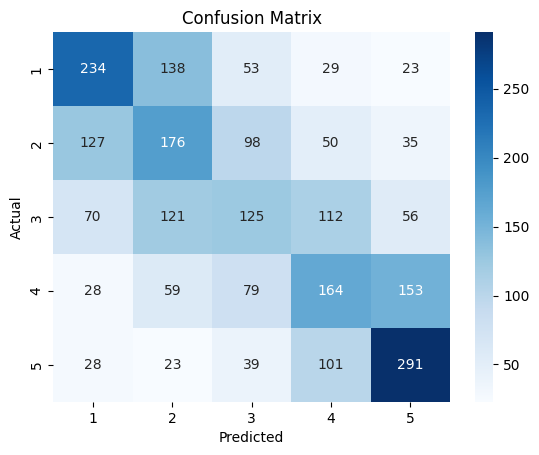

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train SVM

model = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


# Predictions & Evaluation

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


logistic regression

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.43407960199004975

Classification Report:
               precision    recall  f1-score   support

           1       0.51      0.53      0.52       477
           2       0.38      0.37      0.38       486
           3       0.32      0.29      0.30       484
           4       0.37      0.36      0.36       483
           5       0.56      0.62      0.59       482

    accuracy                           0.43      2412
   macro avg       0.43      0.43      0.43      2412
weighted avg       0.43      0.43      0.43      2412



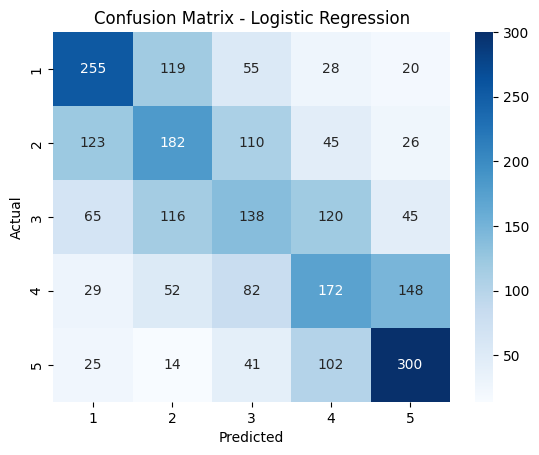

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Train Logistic Regression
log_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    multi_class='auto'
)
log_model.fit(X_train, y_train)


# Predictions & Evaluation
y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Random forest

Accuracy: 0.4187396351575456

Classification Report:
               precision    recall  f1-score   support

           1       0.50      0.49      0.49       477
           2       0.35      0.41      0.38       486
           3       0.35      0.26      0.30       484
           4       0.36      0.29      0.32       483
           5       0.49      0.66      0.56       482

    accuracy                           0.42      2412
   macro avg       0.41      0.42      0.41      2412
weighted avg       0.41      0.42      0.41      2412



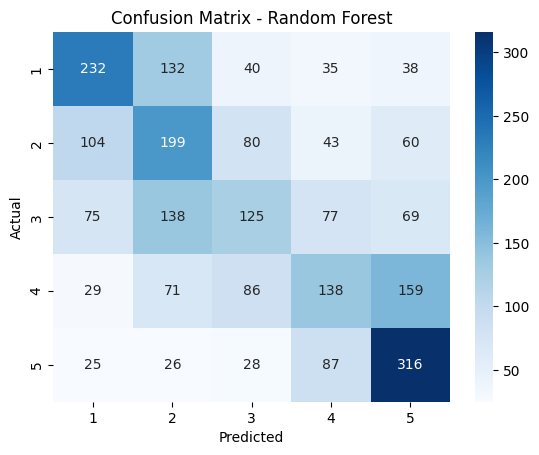

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=None,        # None means nodes are expanded until all leaves are pure
    class_weight='balanced', # handle class imbalance
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


COMPARING

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', multi_class='auto'
    ),
    "SVM": SVC(
        kernel='linear', class_weight='balanced', probability=True, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42
    )
}

# DataFrame to store results
results = []

# Loop through models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision ": report["macro avg"]["precision"],
        "Recall ": report["macro avg"]["recall"],
        "F1-Score ": report["macro avg"]["f1-score"]
    })

# Convert to DataFrame for better display
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                 Model  Accuracy  Precision   Recall   F1-Score 
0  Logistic Regression    0.4336    0.428542   0.4336   0.430695
1                  SVM    0.4264    0.422905   0.4264   0.424193
2        Random Forest    0.4236    0.417658   0.4236   0.417534


HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Parameter grid
log_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"]
}

# Grid search
log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, multi_class='auto'),
    log_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Fit
log_grid.fit(X_train, y_train)

# Results
print("Best Logistic Regression Params:", log_grid.best_params_)
print("Best Logistic Regression Accuracy:", log_grid.best_score_)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Logistic Regression Params: {'C': 1, 'class_weight': None, 'solver': 'liblinear'}
Best Logistic Regression Accuracy: 0.43250005864413676


In [ ]:
pip install joblib


In [ ]:
import joblib


# Save models
joblib.dump(log_model, "Model_A.pkl")

# Also save the TF-IDF vectorizer
joblib.dump(vectorizer, "vectorizer.pkl")


['vectorizer.pkl']

imbalanced (model b) on balanced test data

Accuracy: 0.35447761194029853

Classification Report:
               precision    recall  f1-score   support

           1       0.70      0.15      0.25       477
           2       0.30      0.04      0.07       486
           3       0.26      0.53      0.35       484
           4       0.33      0.40      0.36       483
           5       0.46      0.66      0.54       482

    accuracy                           0.35      2412
   macro avg       0.41      0.35      0.31      2412
weighted avg       0.41      0.35      0.31      2412



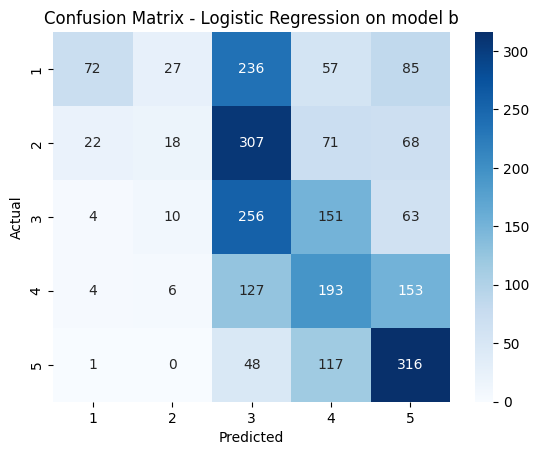

In [ ]:
log_model = joblib.load("Model_B3.pkl")
vectorizer = joblib.load("vectorizer23.pkl") # Load the vectorizer

# Transform X_test using the loaded vectorizer
X_test_transformed = vectorizer.transform(X_test)

# Predictions & Evaluation
y_pred = log_model.predict(X_test_transformed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(set(y_test)),
            yticklabels=sorted(set(y_test)))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression on model b")
plt.show()